# Figuras principais (artigo)

Rode `2_run_ablation.py` antes. Edite só **`CFG`** e a célula **Run**.

| Figura | Função |
|--------|--------|
| Consolidar protocolos → `all_protocols_summary.csv` | célula **Consolidação** |
| Heatmap modalidade×modelo (patient-level AUC ± boot SD) | `plot_heatmap` |
| abs vs t1_only (longitudinal) | `plot_paired` |
| ROC (modelos + faixa ±SD + patient-level AUC ± boot SD) | `plot_roc_models` |
| Matriz de confusão (folds concatenados) | `plot_cm` |
| Tabela métricas — top-2 por task×protocolo×ComBat | `build_results_top_table` |
| Tabela estabilidade (5 modalidades) | `build_stability_table` |
| Estabilidade L1 (1 modalidade, opcional) | `plot_stability` |

In [9]:
import json
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

import importlib
import ablation_analysis

#importlib.reload(ablation_analysis)  # kernel pode ter módulo pré-edit
from ablation_analysis import (
    TIME_ORDER,
    anatomical_key,
    feature_freq_table_grouped,
    filter_ablation_config,
    filter_temporally_stable,
    parse_feature,
    plot_feature_stability_grouped,
    pooled_auc,
    pooled_predictions,
    patient_mean_auc,
    patient_mean_predictions,
    prepare_ablation_df,
    short_anatomical_key,
    summary_with_pooled,
)

# ── editar aqui ──────────────────────────────────────────────
BASE = Path("csvs/longitudinal_4_groups")
SAVE_FIGS = True
ARTIGO_DIR = Path("artigo")
FIG_DIR = ARTIGO_DIR / "figures"
TABLE_DIR = ARTIGO_DIR / "tables"
SUMMARY_PATH = BASE / "all_protocols_summary.csv"

# protocolos na tabela-resumo do artigo vs suplemento
RESULTS_MAIN_PROTOCOLS = ("abs", "t1_only")
RESULTS_SUPP_PROTOCOLS = ("abs", "t1_only", "global", "clinica", "clinica+img", "clinica+img_t1")
RESULTS_TOP_N = 3  # melhores configs por (task, protocolo, ComBat)
RESULTS_TOP_GROUP = ("task", "protocol", "with_combat")

MOD_ORDER = ["vol", "shape", "texture", "disp", "all"]
MODEL_ORDER = ["svm", "rf", "elasticnet"]
ROC_COLORS = {"svm": "#4477AA", "rf": "#EE6677", "elasticnet": "#228833"}
N_BOOT_AUC = 2000  # bootstrap SD da patient-level AUC (subject-averaged OOF; mesmo estimador heatmap/ROC)
STAB_MIN_PCT = 70           # incidência mínima por tempo (%, igual l1_stable)
STAB_MIN_TIMEPOINTS = 0     # ≥2 tempos com pct ≥ STAB_MIN_PCT

MOD_LABELS = {
    "vol": "Volume",
    "shape": "Shape",
    "texture": "Texture",
    "disp": "DVF",
    "all": "All",
}
MODEL_LABELS = {
    "svm": "SVM",
    "rf": "RF",
    "elasticnet": "Elastic-Net",
}

PROTOCOL_ROOTS = {
    "abs": BASE / "ablation_results",
    "t1_only": BASE / "ablation_results_t1_only",
    "global": BASE / "ablation_results_leaky_t1_only",
}


@dataclass(frozen=True)
class CFG:
    selection_mode: str = "l1_stable"
    with_combat: bool = True
    task_primary: str = "smci_pmci"
    task_sanity: str = "cn_ad"
    model_primary: str = "svm"
    modality_primary: str = "vol"
    model_sanity: str = "elasticnet"
    modality_sanity: str = "shape"


CFG = CFG()
TASK_LABELS = {"cn_ad": "CN × AD", "smci_pmci": "sMCI × pMCI"}
CM_LABELS = {
    "cn_ad": ("CN", "AD"),
    "smci_pmci": ("sMCI", "pMCI"),
}


def _csv(mod_dir: Path, stem: str, sel: str) -> Path:
    for name in (f"{stem}_{sel}.csv", f"{stem}.csv"):
        p = mod_dir / name
        if p.is_file():
            return p
    raise FileNotFoundError(f"{stem} ausente em {mod_dir}")


def load_summary(protocol: str, sel: str = CFG.selection_mode) -> pd.DataFrame:
    root = PROTOCOL_ROOTS[protocol]
    frames = []
    for mod in MOD_ORDER:
        d = root / mod
        if not d.is_dir():
            continue
        try:
            frames.append(pd.read_csv(_csv(d, "ablation_summary", sel)))
        except FileNotFoundError:
            pass
    if not frames:
        raise FileNotFoundError(f"sem summary em {root}")
    return pd.concat(frames, ignore_index=True)


def load_ablation(protocol: str, sel: str = CFG.selection_mode) -> pd.DataFrame:
    root = PROTOCOL_ROOTS[protocol]
    frames = []
    for mod in MOD_ORDER:
        d = root / mod
        if not d.is_dir():
            continue
        try:
            frames.append(pd.read_csv(_csv(d, "ablation_results_all", sel)))
        except FileNotFoundError:
            pass
    return prepare_ablation_df(pd.concat(frames, ignore_index=True))


def filter_cfg(df: pd.DataFrame, *, task: str, combat: bool | None = None) -> pd.DataFrame:
    out = df[df["selection_mode"].astype(str) == CFG.selection_mode].copy()
    combat = CFG.with_combat if combat is None else combat
    out = out[out["with_combat"] == combat]
    out = out[out["task"].astype(str) == task]
    return out


def save_fig(fig, name: str) -> None:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    path = FIG_DIR / f"{name}.pdf"
    if SAVE_FIGS:
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print("Salvo:", path)
    plt.show()
    plt.close(fig)


ablation_abs = load_ablation("abs")
summary_abs = summary_with_pooled(ablation_abs)
summary_all = pd.read_csv(SUMMARY_PATH) if SUMMARY_PATH.is_file() else pd.DataFrame()
print(f"Saída → {ARTIGO_DIR} | {CFG.selection_mode} | ComBat={CFG.with_combat}")
print(f"summary_abs recomputado com patient-level AUC (auc_patient_mean) | {len(summary_abs)} configs")
if not summary_all.empty:
    print(f"Summary: {len(summary_all)} linhas em {SUMMARY_PATH.name}")

Saída → artigo | l1_stable | ComBat=True
summary_abs recomputado com patient-level AUC (auc_patient_mean) | 60 configs
Summary: 286 linhas em all_protocols_summary.csv


In [10]:
CONFIG_COLS = ["task", "modality", "model_key", "with_combat", "selection_mode"]
CONSOLIDATION_PROTOCOL_ROOTS = {
    "abs": BASE / "ablation_results",
    "t1_only": BASE / "ablation_results_t1_only",
    "deltas": BASE / "ablation_results_deltas",
    "deltas_only": BASE / "ablation_results_deltas_only",
    "deltas_rel": BASE / "ablation_results_deltas_rel",
    "global": BASE / "ablation_results_leaky",
    "t1_only_global": BASE / "ablation_results_leaky_t1_only",
    "clinica": BASE / "ablation_results_clinic",
    "clinica+img": BASE / "ablation_results_clinic_img",
    "clinica+img_t1": BASE / "ablation_results_clinic_img_t1_only",
}


def _summary_files(root: Path) -> list[Path]:
    # ponytail: glob canônico só no 1º nível — ignora runs antigos aninhados
    files = list(root.glob("*/ablation_summary.csv"))
    files += [f for f in root.glob("*summary*.csv") if not f.name.startswith("all_")]
    return files


def build_all_protocols_summary() -> pd.DataFrame:
    frames = []
    for proto, root in CONSOLIDATION_PROTOCOL_ROOTS.items():
        if not root.is_dir():
            continue
        for f in _summary_files(root):
            df = pd.read_csv(f)
            df.insert(0, "protocol", proto)
            df["source_file"] = str(f.relative_to(BASE))
            df["source_mtime"] = pd.Timestamp(f.stat().st_mtime, unit="s")
            frames.append(df)
    if not frames:
        return pd.DataFrame()
    master = pd.concat(frames, ignore_index=True)
    keys = ["protocol"] + [c for c in CONFIG_COLS if c in master.columns]
    master = master.sort_values("source_mtime").drop_duplicates(keys, keep="last")
    front = ["protocol", *CONFIG_COLS, "auc_patient_mean", "auc_pooled", "auc_mean", "auc_std", "n_features_mean"]
    front = [c for c in front if c in master.columns]
    master = master[front + [c for c in master.columns if c not in front]]
    rank_col = "auc_patient_mean" if "auc_patient_mean" in master.columns else "auc_pooled"
    return master.sort_values(["protocol", rank_col], ascending=[True, False]).reset_index(drop=True)


summary_all = build_all_protocols_summary()
if summary_all.empty:
    print(f"{SUMMARY_PATH.name} vazio — rode ablations antes")
else:
    summary_all.to_csv(SUMMARY_PATH, index=False)
    print(f"Salvo: {SUMMARY_PATH} | {len(summary_all)} linhas")
    print(summary_all.groupby("protocol").size().rename("linhas").to_string())
    show_cols = [c for c in CONFIG_COLS if c in summary_all.columns]
    show_cols += [c for c in ("auc_patient_mean", "auc_pooled") if c in summary_all.columns]
    display(summary_all[show_cols].head(8))

Salvo: csvs/longitudinal_4_groups/all_protocols_summary.csv | 286 linhas
protocol
abs               60
clinica            4
clinica+img       51
clinica+img_t1    30
deltas            16
global             5
t1_only           60
t1_only_global    60


,task,modality,model_key,with_combat,selection_mode,auc_pooled
0,cn_ad,shape,elasticnet,False,l1_stable,0.889329
1,cn_ad,shape,svm,True,l1_stable,0.885222
2,cn_ad,shape,svm,False,l1_stable,0.879303
3,cn_ad,shape,elasticnet,True,l1_stable,0.878942
4,cn_ad,shape,rf,True,l1_stable,0.877537
5,cn_ad,all,elasticnet,True,l1_stable,0.870407
6,cn_ad,shape,rf,False,l1_stable,0.867273
7,cn_ad,texture,svm,True,l1_stable,0.863800


In [11]:
def _patient_mean_cell(df: pd.DataFrame, *, task: str, modality: str, model: str) -> tuple[float, float]:
    """Patient-level AUC (subject-averaged OOF) + bootstrap SD (mesmo estimador ROC)."""
    sub = filter_ablation_config(
        df, task=task, modality=modality, model_key=model,
        with_combat=CFG.with_combat, selection_mode=CFG.selection_mode,
    )
    y, s = patient_mean_predictions(sub)
    auc = float(roc_auc_score(y, s))
    sd = bootstrap_auc_std(y, s)
    return auc, sd


def plot_heatmap(df, task: str, *, title: str, fname: str, vmin=0.5, vmax=1.0):
    """Heatmap patient-level AUC ± bootstrap SD (ablation raw, não summary)."""
    sub = filter_cfg(df, task=task)
    mods = [m for m in MOD_ORDER if m in sub["modality"].astype(str).unique()]
    models = [m for m in MODEL_ORDER if m in sub["model_key"].astype(str).unique()]
    auc_w = pd.DataFrame(index=models, columns=mods, dtype=float)
    sd_w = pd.DataFrame(index=models, columns=mods, dtype=float)
    for model in models:
        for mod in mods:
            try:
                auc, sd = _patient_mean_cell(df, task=task, modality=mod, model=model)
            except (ValueError, KeyError) as e:
                print(f"heatmap skip {task}/{mod}/{model}: {e}")
                continue
            auc_w.loc[model, mod] = auc
            sd_w.loc[model, mod] = sd
    auc_w = auc_w.rename(index=MODEL_LABELS, columns=MOD_LABELS)
    sd_w = sd_w.rename(index=MODEL_LABELS, columns=MOD_LABELS)
    annot = np.array([
        ["" if pd.isna(p) else f"{p:.3f}±{s:.2f}" for p, s in zip(auc_w.iloc[i], sd_w.iloc[i])]
        for i in range(len(auc_w))
    ])
    fig, ax = plt.subplots(figsize=(6, 3.5))
    sns.heatmap(auc_w.astype(float), annot=annot, fmt="", cmap="YlOrRd",
                vmin=vmin, vmax=vmax, ax=ax, cbar_kws={"label": "Patient-level AUC"})
    ax.set_xlabel("Modality")
    ax.set_ylabel("Classifier")
    ax.set_title(title)
    plt.tight_layout()
    save_fig(fig, fname)


def plot_paired(protocols: tuple[str, ...], task: str, model: str, *, title: str, fname: str, labels: dict | None = None):
    """Barras pareadas por modalidade (patient-level AUC)."""
    labels = labels or {p: p for p in protocols}
    rows = []
    for proto in protocols:
        raw = load_ablation(proto)
        for mod in MOD_ORDER:
            try:
                auc, _ = _patient_mean_cell(raw, task=task, modality=mod, model=model)
            except (ValueError, KeyError, FileNotFoundError):
                continue
            rows.append({"modality": mod, "protocol": proto, "auc": auc})
    plot_df = pd.DataFrame(rows)
    if plot_df.empty:
        print(f"plot_paired vazio: {protocols} | {task} | {model}")
        return
    wide = plot_df.pivot(index="modality", columns="protocol", values="auc").reindex(
        [m for m in MOD_ORDER if m in plot_df["modality"].unique()]
    )
    x = np.arange(len(wide))
    w = 0.8 / len(protocols)
    fig, ax = plt.subplots(figsize=(7, 4))
    for i, proto in enumerate(protocols):
        if proto not in wide.columns:
            continue
        ax.bar(x + (i - (len(protocols) - 1) / 2) * w, wide[proto], w, label=labels.get(proto, proto))
    ax.set_xticks(x, wide.index)
    y_max = min(1.0, max(0.8, np.ceil((np.nanmax(wide.to_numpy()) + 0.08) * 10) / 10))
    ax.set_ylim(0.0, y_max)
    ax.axhline(0.5, color="gray", ls="--", lw=0.8)
    ax.set_ylabel("Patient-level AUC")
    ax.set_title(title)
    ax.legend(loc="upper right")
    plt.tight_layout()
    save_fig(fig, fname)


def _interp_tpr(fpr, tpr, grid: np.ndarray) -> np.ndarray:
    return np.interp(grid, fpr, tpr, left=0.0, right=1.0)


def roc_fold_bands(sub: pd.DataFrame, fpr_grid: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """TPR médio ± SD entre avaliações externas (fold × repeat)."""
    tpr_rows: list[np.ndarray] = []
    for _, row in sub.iterrows():
        y = np.asarray(json.loads(row["test_y_true"]), dtype=int)
        s = np.asarray(json.loads(row["test_scores"]), dtype=float)
        if len(np.unique(y)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y, s)
        tpr_rows.append(_interp_tpr(fpr, tpr, fpr_grid))
    if not tpr_rows:
        raise ValueError("Nenhum fold com duas classes")
    stack = np.vstack(tpr_rows)
    return stack.mean(axis=0), stack.std(axis=0, ddof=0)


def bootstrap_auc_std(y, scores, *, n_boot: int = N_BOOT_AUC, seed: int = 0) -> float:
    """SD da AUC (patient-level / subject-averaged OOF ou pooled) por bootstrap nas predições agregadas."""
    y = np.asarray(y, dtype=int)
    scores = np.asarray(scores, dtype=float)
    rng = np.random.default_rng(seed)
    aucs: list[float] = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y), size=len(y))
        yb, sb = y[idx], scores[idx]
        if len(np.unique(yb)) < 2:
            continue
        aucs.append(float(roc_auc_score(yb, sb)))
    if not aucs:
        return float("nan")
    return float(np.std(aucs, ddof=0))


def plot_roc_models(
    df,
    task: str,
    mod: str,
    *,
    title: str,
    fname: str,
    models: list[str] | None = None,
    score_agg: str = "patient_mean",
):
    """ROC: faixa = ±SD TPR entre folds; legenda = patient-level AUC ± bootstrap SD."""
    agg_fn = patient_mean_predictions if score_agg == "patient_mean" else pooled_predictions
    models = models or MODEL_ORDER
    fpr_grid = np.linspace(0, 1, 101)
    fig, ax = plt.subplots(figsize=(6, 5.5))
    for i, model in enumerate(models):
        try:
            sub = filter_ablation_config(
                df, task=task, modality=mod, model_key=model,
                with_combat=CFG.with_combat, selection_mode=CFG.selection_mode,
            )
        except ValueError as e:
            print(f"ROC skip {model}: {e}")
            continue
        tpr_m, tpr_s = roc_fold_bands(sub, fpr_grid)
        y, scores = agg_fn(sub)
        auc = float(roc_auc_score(y, scores))
        sd = bootstrap_auc_std(y, scores, seed=100 + i)
        color = ROC_COLORS.get(model, f"C{i}")
        ax.fill_between(
            fpr_grid,
            np.clip(tpr_m - tpr_s, 0, 1),
            np.clip(tpr_m + tpr_s, 0, 1),
            color=color, alpha=0.22, linewidth=0,
        )
        model_label = MODEL_LABELS.get(model, model)
        ax.plot(fpr_grid, tpr_m, color=color, lw=2, label=f"{model_label}  {auc:.3f}±{sd:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.text(
        0.03, 0.97, TASK_LABELS.get(task, task), transform=ax.transAxes,
        va="top", ha="left", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="0.85", edgecolor="0.6"),
    )
    ax.set_xlabel("False Positive Rate (FPR)")
    ax.set_ylabel("True Positive Rate (TPR)")
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=10, title="Patient-level AUC ± SD")
    ax.set_aspect("equal")
    plt.tight_layout()
    save_fig(fig, fname)


def plot_cm(df, task: str, mod: str, model: str, *, title: str, fname: str):
    sub = filter_ablation_config(
        df, task=task, modality=mod, model_key=model,
        with_combat=CFG.with_combat, selection_mode=CFG.selection_mode,
    )
    yt, yp = [], []
    for _, row in sub.iterrows():
        y = json.loads(row["test_y_true"])
        s = np.asarray(json.loads(row["test_scores"]), dtype=float)
        thr = float(row["threshold"])
        yt.extend(y)
        yp.extend((s >= thr).astype(int).tolist())
    cm = confusion_matrix(yt, yp, labels=[0, 1])
    neg, pos = CM_LABELS[task]
    fig, ax = plt.subplots(figsize=(4.2, 3.8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=[neg, pos], yticklabels=[neg, pos], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    save_fig(fig, fname)


def _time_order_from_sub(sub: pd.DataFrame) -> tuple[str, ...]:
    tokens: set[str] = set()
    for _, row in sub.iterrows():
        for feat in json.loads(row["selected_features"]):
            p = parse_feature(feat)
            if p:
                tokens.add(p[1])
    if tokens & {"D21", "D31", "D32"}:
        return ("T1", "D21", "D31", "D32")
    if tokens & {"D21", "D31", "SLOPE"}:
        return ("T1", "D21", "D31", "SLOPE")
    return tuple(t for t in TIME_ORDER if t in tokens) or TIME_ORDER


def _fold_flags(sub: pd.DataFrame, feature_group: str, time_order: tuple[str, ...]) -> dict[str, np.ndarray]:
    """Por fold: seleção 0/1 (any + cada visita/representação)."""
    sub = prepare_ablation_df(sub)
    any_f = []
    by_time = {t: [] for t in time_order}
    for _, row in sub.iterrows():
        times: set[str] = set()
        for feat in json.loads(row["selected_features"]):
            if anatomical_key(feat) != feature_group:
                continue
            parsed = parse_feature(feat)
            if parsed:
                times.add(parsed[1])
        any_f.append(int(bool(times)))
        for t in time_order:
            by_time[t].append(int(t in times))
    return {"any": np.asarray(any_f), **{t: np.asarray(v) for t, v in by_time.items()}}


def build_stability_table(
    df,
    task: str,
    model: str,
    *,
    modalities: list[str] | None = None,
    min_pct: int = STAB_MIN_PCT,
    min_timepoints: int = STAB_MIN_TIMEPOINTS,
) -> pd.DataFrame:
    """Tabela longa: modalidade × atributo estável (≥min_pct em ≥min_timepoints tempos)."""
    modalities = modalities or MOD_ORDER
    rows: list[dict] = []
    for mod in modalities:
        try:
            sub = filter_ablation_config(
                df, task=task, modality=mod, model_key=model,
                with_combat=CFG.with_combat, selection_mode=CFG.selection_mode,
            )
        except ValueError:
            continue
        grp = feature_freq_table_grouped(sub, min_coverage=0.0)
        grp = filter_temporally_stable(grp, min_pct=min_pct, min_timepoints=min_timepoints)
        if grp.empty:
            continue
        time_order = _time_order_from_sub(sub)
        for _, r in grp.iterrows():
            flags = _fold_flags(sub, r["feature_group"], time_order)
            row = {
                "modality": mod,
                "feature": r["feature_short"],
                "coverage_pct": r["coverage_pct"],
                "sd_fold": float(flags["any"].std(ddof=0)),
            }
            for t in time_order:
                col = f"pct_{t}"
                if col in r.index:
                    row[col] = r[col]
                    row[f"sd_{t}"] = float(flags[t].std(ddof=0))
            rows.append(row)
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(
        ["modality", "coverage_pct", "feature"], ascending=[True, False, True],
    ).reset_index(drop=True)


METRIC_PAIRS = (
    ("auc_mean", "auc_std", "auc"),
    ("accuracy_mean", "accuracy_std", "acc"),
    ("bal_acc_mean", "bal_acc_std", "bacc"),
    ("mcc_mean", "mcc_std", "mcc"),
    ("f1_pos_mean", "f1_pos_std", "f1"),
    ("sens_pos_mean", "sens_pos_std", "sens"),
    ("spec_neg_mean", "spec_neg_std", "spec"),
    ("auc_pr_mean", "auc_pr_std", "auc_pr"),
)
RESULT_ID_COLS = ("protocol", "task", "modality", "model_key", "with_combat", "selection_mode")


def _fmt_ms(mean, std, digits: int = 3) -> str:
    if pd.isna(mean):
        return ""
    if std is None or pd.isna(std):
        return f"{float(mean):.{digits}f}"
    return f"{float(mean):.{digits}f}±{float(std):.{digits}f}"


def _filter_results_summary(
    summary: pd.DataFrame,
    *,
    tasks: tuple[str, ...] | None = None,
    protocols: tuple[str, ...] | None = None,
    selection_mode: str | None = None,
    with_combat: bool | None = None,
) -> pd.DataFrame:
    out = summary.copy()
    if tasks:
        out = out[out["task"].astype(str).isin(tasks)]
    if protocols:
        out = out[out["protocol"].astype(str).isin(protocols)]
    if selection_mode:
        out = out[out["selection_mode"].astype(str) == selection_mode]
    if with_combat is not None:
        out = out[out["with_combat"] == with_combat]
    return out.reset_index(drop=True)


def _format_results_metrics(out: pd.DataFrame) -> pd.DataFrame:
    out = out.copy()
    out["task_label"] = out["task"].map(TASK_LABELS).fillna(out["task"])
    out["combat"] = np.where(out["with_combat"], "ComBat", "no ComBat")
    for mean_col, std_col, label in METRIC_PAIRS:
        if mean_col not in out.columns:
            continue
        std_col = std_col if std_col in out.columns else None
        out[label] = out.apply(
            lambda r, m=mean_col, s=std_col: _fmt_ms(r[m], r[s] if s else None), axis=1,
        )
    show = [
        "rank", "protocol", "task_label", "task", "modality", "model_key", "combat", "with_combat",
        "selection_mode", "auc_patient_mean", "auc_pooled", "n_features_mean", "n_outer_evals",
    ]
    show += [label for _, _, label in METRIC_PAIRS if label in out.columns]
    show = [c for c in show if c in out.columns]
    return out[show]


def build_results_table(
    summary: pd.DataFrame,
    *,
    tasks: tuple[str, ...] | None = None,
    protocols: tuple[str, ...] | None = None,
    selection_mode: str | None = None,
    with_combat: bool | None = None,
) -> pd.DataFrame:
    """Tabela completa com patient-level AUC (se houver) + pooled + métricas mean±SD."""
    out = _filter_results_summary(
        summary, tasks=tasks, protocols=protocols,
        selection_mode=selection_mode, with_combat=with_combat,
    )
    if out.empty:
        return out
    out = _format_results_metrics(out)
    sort_cols = [c for c in ("task", "protocol", "with_combat", "modality", "model_key") if c in out.columns]
    return out.sort_values(sort_cols).reset_index(drop=True)


def _auc_rank_col(df: pd.DataFrame) -> str:
    return "auc_patient_mean" if "auc_patient_mean" in df.columns else "auc_pooled"


def build_results_top_table(
    summary: pd.DataFrame,
    *,
    tasks: tuple[str, ...] | None = None,
    protocols: tuple[str, ...] | None = None,
    selection_mode: str | None = None,
    group_cols: tuple[str, ...] = RESULTS_TOP_GROUP,
    n_top: int = RESULTS_TOP_N,
) -> pd.DataFrame:
    """Top-N por patient-level AUC (fallback: pooled) — inclui ComBat on/off."""
    raw = _filter_results_summary(
        summary, tasks=tasks, protocols=protocols,
        selection_mode=selection_mode, with_combat=None,
    )
    if raw.empty:
        return raw
    rank_col = _auc_rank_col(raw)
    group_cols = tuple(c for c in group_cols if c in raw.columns)
    raw = raw.sort_values(
        list(group_cols) + [rank_col],
        ascending=[True] * len(group_cols) + [False],
    )
    raw["rank"] = raw.groupby(list(group_cols), sort=False).cumcount() + 1
    raw = raw[raw["rank"] <= n_top].copy()
    out = _format_results_metrics(raw)
    return out.sort_values(rank_col, ascending=False).reset_index(drop=True)


def save_table(tbl: pd.DataFrame, fname: str) -> Path | None:
    if tbl.empty or not SAVE_FIGS:
        return None
    TABLE_DIR.mkdir(parents=True, exist_ok=True)
    path = TABLE_DIR / f"{fname}.csv"
    tbl.to_csv(path, index=False)
    print("Salvo:", path)
    return path


def save_stability_table(tbl: pd.DataFrame, fname: str) -> Path | None:
    return save_table(tbl, fname)


def plot_stability(df, task: str, mod: str, model: str, *, title: str, fname: str):
    sub = filter_ablation_config(
        df, task=task, modality=mod, model_key=model,
        with_combat=CFG.with_combat, selection_mode=CFG.selection_mode,
    )
    out = FIG_DIR / f"{fname}.pdf" if SAVE_FIGS else None
    fig = plot_feature_stability_grouped(sub, title=title, out_path=out)
    if SAVE_FIGS:
        print("Salvo:", out)
    plt.show()
    plt.close(fig)


def plot_combat(summary, task: str, model: str, *, title: str, fname: str):
    """ComBat off vs on (mesmo protocolo abs) — patient-level AUC."""
    auc_col = "auc_patient_mean" if "auc_patient_mean" in summary.columns else "auc_pooled"
    rows = []
    for combat, label in ((False, "no ComBat"), (True, "ComBat")):
        sub = summary[
            (summary["with_combat"] == combat)
            & (summary["task"].astype(str) == task)
            & (summary["model_key"].astype(str) == model)
            & (summary["selection_mode"].astype(str) == CFG.selection_mode)
        ]
        for _, r in sub.iterrows():
            rows.append({"modality": r["modality"], "combat": label, "auc": r[auc_col]})
    plot_df = pd.DataFrame(rows)
    wide = plot_df.pivot(index="modality", columns="combat", values="auc").reindex(
        [m for m in MOD_ORDER if m in plot_df["modality"].unique()]
    )
    x = np.arange(len(wide))
    w = 0.35
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(x - w / 2, wide["no ComBat"], w, label="No Harmonization")
    ax.bar(x + w / 2, wide["ComBat"], w, label="With Harmonization")
    ax.set_xticks(x, wide.index)
    y_max = min(1.0, max(0.8, np.ceil((np.nanmax(wide.to_numpy()) + 0.08) * 10) / 10))
    ax.set_ylim(0.0, y_max)
    ax.axhline(0.5, color="gray", ls="--", lw=0.8)
    ax.set_ylabel("Patient-level AUC" if auc_col == "auc_patient_mean" else "AUC pooled")
    ax.set_title(title)
    ax.legend(loc="upper right")
    plt.tight_layout()
    save_fig(fig, fname)

Salvo: artigo/figures/heatmap_smci_pmci.pdf


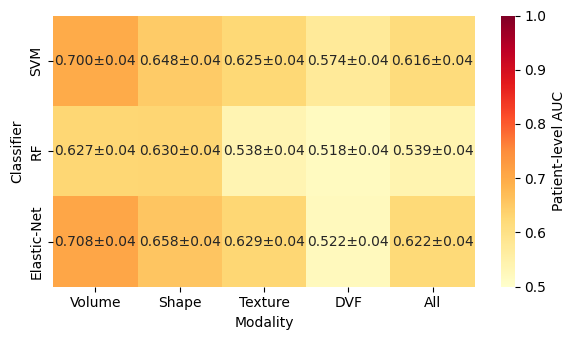

Salvo: artigo/figures/heatmap_cn_ad.pdf


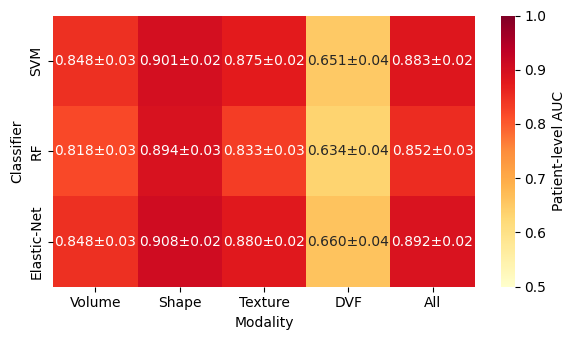

Salvo: artigo/figures/abs_t1only.pdf


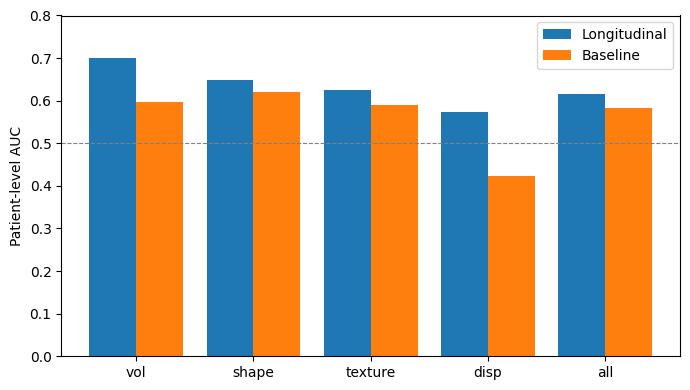

Salvo: artigo/figures/roc_smci_pmci.pdf


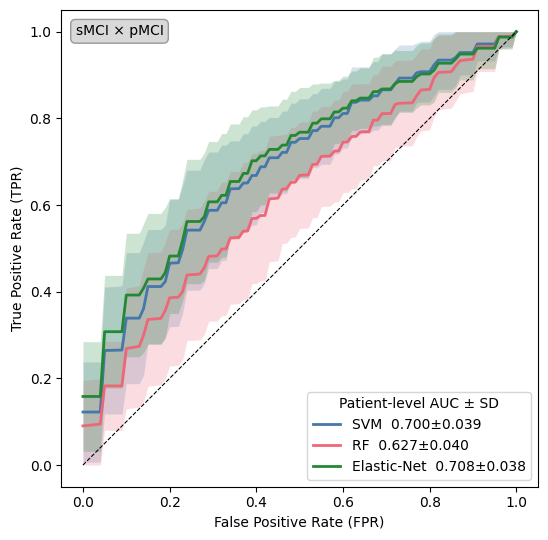

Salvo: artigo/figures/roc_cn_ad.pdf


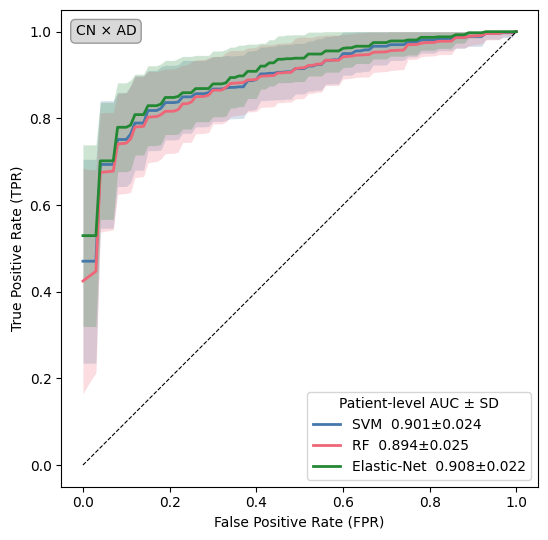

Salvo: artigo/figures/cm_smci_pmci.pdf


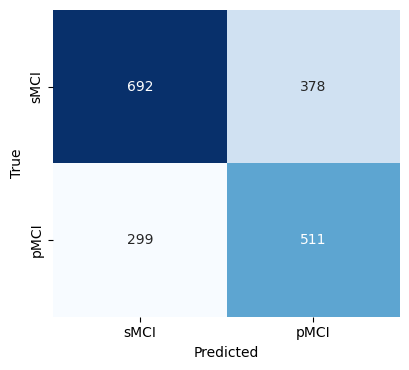

Salvo: artigo/figures/cm_cn_ad.pdf


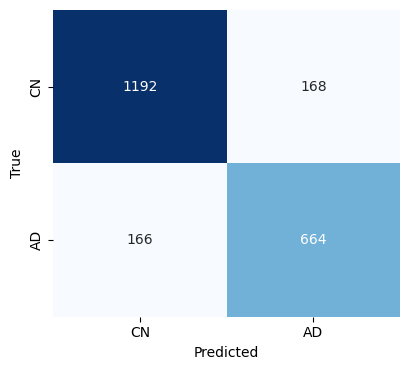

Tabela main (top-3 por ('task', 'protocol', 'with_combat')) | l1_stable | 12 linhas


,protocol,task,modality,model_key,with_combat,auc_pooled,n_features_mean,acc,bacc,f1,sens,spec
0,abs,smci_pmci,vol,elasticnet,True,0.694408,15.64,0.649±0.065,0.647±0.064,0.605±0.086,0.639±0.145,0.655±0.138
1,abs,smci_pmci,vol,svm,True,0.681635,16.38,0.640±0.063,0.639±0.065,0.597±0.083,0.631±0.134,0.647±0.109
2,abs,smci_pmci,vol,elasticnet,False,0.670845,15.02,0.624±0.066,0.620±0.063,0.565±0.092,0.589±0.166,0.650±0.166
3,abs,smci_pmci,vol,svm,False,0.656015,16.26,0.613±0.067,0.607±0.071,0.546±0.106,0.559±0.151,0.654±0.112
4,t1_only,smci_pmci,shape,rf,False,0.647864,17.64,0.581±0.048,0.599±0.051,0.589±0.091,0.726±0.181,0.472±0.145
5,abs,smci_pmci,shape,elasticnet,True,0.634061,24.18,0.596±0.078,0.593±0.074,0.539±0.101,0.570±0.174,0.616±0.177
6,abs,smci_pmci,shape,elasticnet,False,0.631115,17.80,0.572±0.075,0.567±0.077,0.493±0.147,0.530±0.223,0.604±0.192
7,t1_only,smci_pmci,vol,elasticnet,True,0.622894,3.04,0.577±0.079,0.580±0.090,0.509±0.201,0.597±0.269,0.562±0.181
8,t1_only,smci_pmci,vol,elasticnet,False,0.617563,3.20,0.583±0.070,0.587±0.077,0.523±0.183,0.611±0.254,0.563±0.189
9,t1_only,smci_pmci,shape,elasticnet,False,0.617127,10.00,0.563±0.074,0.567±0.070,0.503±0.168,0.595±0.273,0.539±0.256


Salvo: artigo/tables/main_results.csv
Tabela estabilidade | sMCI × pMCI | svm | ≥70% em ≥0 tempos


,modality,feature,coverage_pct,sd_fold,pct_T1,sd_T1,pct_T2,sd_T2,pct_T3,sd_T3
0,all,L | original_glcm_Autocorrelation,100,0.00,100,0.000000,100,0.00,100,0.000000
1,all,L | original_gldm_LargeDependenceHighGrayLevel...,100,0.00,100,0.000000,100,0.00,100,0.000000
2,all,L | original_glrlm_RunLengthNonUniformity,100,0.00,100,0.000000,100,0.00,98,0.140000
3,all,L | original_glszm_LargeAreaHighGrayLevelEmphasis,100,0.00,100,0.000000,100,0.00,100,0.000000
4,all,R | original_gldm_LargeDependenceHighGrayLevel...,100,0.00,100,0.000000,100,0.00,100,0.000000
...,...,...,...,...,...,...,...,...,...,...
84,vol,L | gm_norm,100,0.00,100,0.000000,100,0.00,100,0.000000
85,vol,R | csf_norm,100,0.00,100,0.000000,100,0.00,100,0.000000
86,vol,R | gm_norm,100,0.00,100,0.000000,100,0.00,100,0.000000
87,vol,R | wm_norm,100,0.00,56,0.496387,100,0.00,22,0.414246


Salvo: artigo/tables/stability.csv
Salvo: artigo/figures/abs_global.pdf


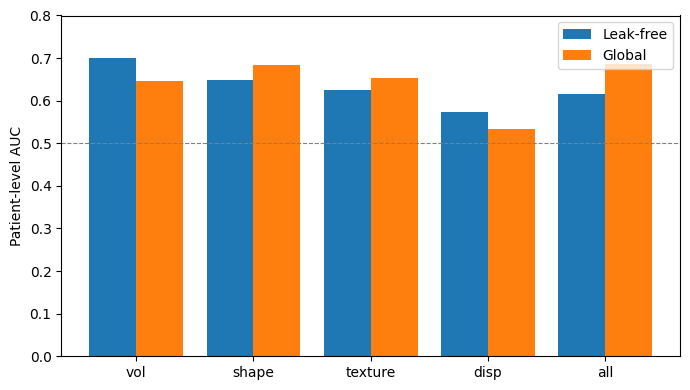

Salvo: artigo/figures/combat.pdf


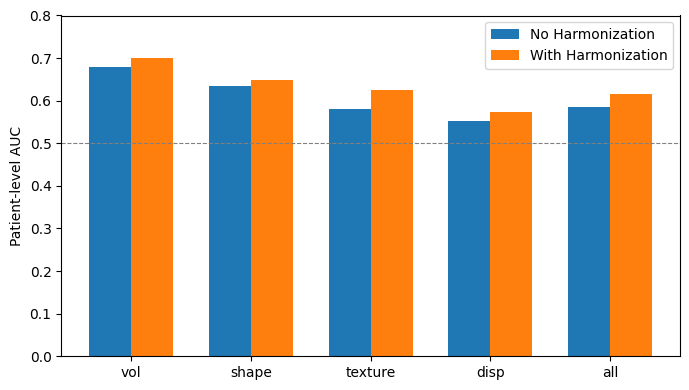

In [12]:
# ── Run: edite title/fname ou comente linhas ─────────────────
_tag = f"{CFG.selection_mode}_" + ("combat" if CFG.with_combat else "nocombat")

# 1. Heatmaps (modalidade × modelo) — patient-level AUC ± boot SD
plot_heatmap(
    ablation_abs, CFG.task_primary,
    title=f"",#patient-level AUC±boot SD — {TASK_LABELS[CFG.task_primary]} ({_tag})",
    fname=f"heatmap_{CFG.task_primary}",
)
plot_heatmap(
    ablation_abs, CFG.task_sanity,
    title=f"",#patient-level AUC±boot SD — {TASK_LABELS[CFG.task_sanity]} ({_tag})",
    fname=f"heatmap_{CFG.task_sanity}",
)

# 2. Longitudinal: abs vs t1_only
plot_paired(
    ("abs", "t1_only"), CFG.task_primary, CFG.model_primary,
    labels={"abs": "Longitudinal", "t1_only": "Baseline"},
    title=f"", #abs vs t1_only | {TASK_LABELS[CFG.task_primary]} | {CFG.model_primary}",
    fname=f"abs_t1only",
)

# 3. ROC patient-level (subject-averaged OOF) — todos os modelos
plot_roc_models(
    ablation_abs, CFG.task_primary, CFG.modality_primary,
    title=f"",#ROC patient-level — {TASK_LABELS[CFG.task_primary]} | {CFG.modality_primary}",
    fname=f"roc_{CFG.task_primary}",
    score_agg="patient_mean",
)
plot_roc_models(
    ablation_abs, CFG.task_sanity, CFG.modality_sanity,
    title=f"",#ROC patient-level — {TASK_LABELS[CFG.task_sanity]} | {CFG.modality_sanity}",
    fname=f"roc_{CFG.task_sanity}",
    score_agg="patient_mean",
)

# 4. Matriz de confusão (Youden por fold)
plot_cm(
    ablation_abs, CFG.task_primary, CFG.modality_primary, CFG.model_primary,
    title=f"",#CM pooled — {TASK_LABELS[CFG.task_primary]} | {CFG.modality_primary} | {CFG.model_primary}",
    fname=f"cm_{CFG.task_primary}",
)
plot_cm(
    ablation_abs, CFG.task_sanity, CFG.modality_sanity, CFG.model_sanity,
    title=f"",#CM pooled — {TASK_LABELS[CFG.task_sanity]} | {CFG.modality_sanity} | {CFG.model_sanity}",
    fname=f"cm_{CFG.task_sanity}",
)

# 6. Tabelas de métricas
if not summary_all.empty:
    results_main = build_results_top_table(
        summary_all,
        tasks=("smci_pmci",),
        protocols=RESULTS_MAIN_PROTOCOLS,
        selection_mode=CFG.selection_mode,
        n_top=RESULTS_TOP_N,
    )

    # tabela main: manter só smci_pmci + remover colunas pedidas
    drop_cols = [
        "rank",
        "task_label",
        "combat",
        "selection_mode",
        "n_outer_evals",
        "auc",
        "mcc",
        "auc_pr",
    ]
    results_main = results_main.drop(columns=[c for c in drop_cols if c in results_main.columns])

    print(
        f"Tabela main (top-{RESULTS_TOP_N} por {RESULTS_TOP_GROUP}) | "
        f"{CFG.selection_mode} | {len(results_main)} linhas"
    )
    display(results_main)
    save_table(results_main, f"main_results")
else:
    print("all_protocols_summary.csv ausente — rode a célula de consolidação acima")

# 5. Estabilidade — tabela (5 modalidades)
stab_tbl = build_stability_table(ablation_abs, CFG.task_primary, CFG.model_primary)
print(
    f"Tabela estabilidade | {TASK_LABELS[CFG.task_primary]} | {CFG.model_primary} "
    f"| ≥{STAB_MIN_PCT}% em ≥{STAB_MIN_TIMEPOINTS} tempos"
)
display(stab_tbl)
save_stability_table(
    stab_tbl,
    f"stability",
)

# # Opcional: gráfico de linhas só na modalidade primária
# plot_stability(
#     ablation_abs, CFG.task_primary, CFG.modality_primary, CFG.model_primary,
#     title=f"Estabilidade L1 — {CFG.modality_primary} | {CFG.model_primary}",
#     fname=f"stability_{CFG.task_primary}_{CFG.modality_primary}_{CFG.model_primary}_{_tag}",
# )

# ── Suplemento (descomente se precisar) ──────────────────────
plot_paired(
    ("abs", "global"), CFG.task_primary, CFG.model_primary,
    labels={"abs": "Leak-free", "global": "Global"},
    title=f"", #abs vs global | {CFG.task_primary}",
    fname=f"abs_global",
)
plot_combat(
    summary_abs, CFG.task_primary, CFG.model_primary,
    title=f"", #ComBat | {CFG.task_primary} | {CFG.model_primary}",
    fname=f"combat",
)